# X-ray luminosity light curve

Unabsorbed **0.3-10 keV** X-ray luminosity vs. phase for the 3 unique SN 2018ivc
X-ray epochs, using each epoch's adopted best-fit model (per
`xray_epoch_spec_models.xlsx` and
`figure_notebooks/xray_spectra_best_model_by_epoch.ipynb`).

**Updated 2026-09-07:** flux/luminosity computed via PyXspec's `lum`/`flux`
commands (each epoch's adopted model refit directly in XSPEC, background loaded but
not subtracted, `cstat` which XSPEC applies as the W-statistic automatically when a
background is present) rather than Sherpa's `sample_flux` -- see
`data/Chandra/spectral_fitting/xray_flux_luminosity_pyxspec.py`. Distance is
**Maeda et al. 2023b, D = 10 (+1.8/-1.5) Mpc** (not the Cepheid 10.72 Mpc used
previously), implemented via an "effective H0" trick (`lum`'s luminosity distance
comes from redshift+cosmology, not a directly specified Mpc value; solved for the
H0 that reproduces the target D_L at NGC 1068's z=0.003793, verified numerically
against the exact cosmological D_L to <0.5%).

**Updated 2026-09-08: band switched from 0.3-8 keV to 0.3-10 keV.** Comparing
against an independent light curve the user's advisor made
(`figures/Poonam_xray_LC.png`, labeled 0.3-10 keV) showed our two analyses
disagreed by a uniform ~3-4x. Testing two hypotheses in turn: (1) distance --
already fixed above (naive Hubble-flow D~16.2 Mpc vs. the peculiar-velocity-
corrected Maeda D=10 Mpc closes most of the gap on its own) and (2) energy band --
switching from 0.3-8 to 0.3-10 keV (matching ACIS's full nominal calibrated
bandpass, `redback-csm`'s default, and the advisor's own plot) closes the small
remainder: isolated band-effect residual ratios landed at 0.99/0.93/1.08 for the
three epochs (vs. Poonam's plot, both evaluated at the same naive distance to
isolate the band effect alone) -- i.e. the two analyses now agree to within
plot-read-off precision. Data source:
`data/Chandra/spectral_fitting/xray_flux_luminosity_pyxspec_0p3_10kev.py` / `fits/
xray_flux_luminosity_pyxspec_0p3_10kev.csv`. Full writeup: `CLAUDE_xray_SOP.md`
Step 5.

**Caveat carried into this figure:** none of the 3 epochs have any source counts
above ~6.4-7.2 keV once grouped at 15 counts/bin (`QUALITY==0` channels stop
there) -- refitting at 0.3-10 keV gives the *identical* fit statistic/dof as the
0.3-8 keV version (confirmed), since the wider band adds zero new constraining
data. The 8-10 keV contribution to the plotted flux/luminosity is therefore pure
model extrapolation of the best-fit continuum past the last channel any data
actually constrains, not a directly measured excess. Legitimate standard use of
`flux`/`lumin` (they integrate the best-fit model over whatever band is asked,
independent of the noticed data range), but worth keeping in mind before treating
these numbers as purely data-driven.

**Error bars fold the distance systematic in**: plotted error = quadrature sum,
per side, of the flux-statistical error (covariance-based MC at the central
D=10 Mpc) and the distance-systematic bracket (point-estimate luminosity at the
Maeda +1.8/-1.5 Mpc bounds).

Note: 29071+29072's statistical error is degenerate/one-sided (huge upper bound --
an already-known parameter degeneracy in its bremss+powerlaw fit) -- its plotted
lower error bar is dominated by the distance systematic since the statistical
low-side is small, while the upper error bar is enormous and not very informative.
Not investigated further per the user's request to defer that.

**Color: each epoch's point uses its position in the single project-wide viridis
epoch list** (`CLAUDE_plotting.md`), same mapping as every other epoch-colored
figure in this project (the X-ray spectral fit comparison figures, the radio SEDs).
Log-log axes per the project's general light-curve/SED formatting convention.

This is data only -- no CSM-interaction model curve yet (that's Step 6,
`redback-csm`, not started). Run under the `18ivc_clean` kernel.

**Updated 2026-09-09: added a second panel showing the hardness ratio** (HR =
F(2-8 keV)/F(0.3-2 keV), absorbed flux) vs. the same phase axis, sharing the
x-axis with the luminosity panel above it -- per `CLAUDE_xray_SOP.md` Step
5.5. Data: `data/Chandra/spectral_fitting/fits/xray_hardness_ratio.csv`
(same per-epoch adopted models as the luminosity panel, but absorbed flux in
two sub-bands instead of unabsorbed flux in one broad band, and correlated
covariance-based MC error propagation on the ratio -- see Step 5.5 for full
methodology). This supersedes the standalone
`figure_notebooks/xray_hardness_ratio.ipynb` figure, which is no longer
regenerated.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import functions

functions.set_plot_style()

FLUX_LUM_CSV = "../data/Chandra/spectral_fitting/fits/xray_flux_luminosity_pyxspec_0p3_10kev.csv"
HR_CSV = "../data/Chandra/spectral_fitting/fits/xray_hardness_ratio.csv"

# Position of each X-ray epoch in the single project-wide viridis epoch list
# (CLAUDE_plotting.md "Epoch -> viridis color (SEDs)", x = linspace(1,0,11)).
EPOCH_VIRIDIS_X = {
    "20306": 0.900,
    "29071_29072": 0.400,
    "31211_31996": 0.100,
}
# Legend labels: calendar observation date(s), read from each PHA's DATE-OBS
# header (2026-09-14, replacing raw ObsIDs -- see git history for the prior
# "20306"/"29071+29072"/"31211+31996" labels). 20306 and the two merged
# epochs' constituent ObsIDs:
#   20306                    DATE-OBS 2018-12-05T16:39:26
#   29071                    DATE-OBS 2024-01-04T17:29:12
#   29072                    DATE-OBS 2024-01-28T17:36:25
#   31211                    DATE-OBS 2025-11-16T08:06:13
#   31996                    DATE-OBS 2025-11-16T17:44:21
# 29071+29072 span 24 days apart (shown as a range); 31211+31996 are same-day
# (shown as a single date).
EPOCH_LABELS = {
    "20306": "2018 Dec 05",
    "29071_29072": "2024 Jan 04–28",
    "31211_31996": "2025 Nov 16",
}

cmap = mpl.colormaps["viridis"]
epoch_colors = {k: cmap(x) for k, x in EPOCH_VIRIDIS_X.items()}

df = pd.read_csv(FLUX_LUM_CSV, dtype={"epoch": str}).set_index("epoch")
hr_df = pd.read_csv(HR_CSV, dtype={"epoch": str}).set_index("epoch")

# Fold the Maeda et al. 2023b distance systematic into the plotted error bars:
# quadrature sum, per side, of the flux-statistical error (from PyXspec's
# covariance-based MC at the central D=10 Mpc) and the distance-systematic
# bracket (point-estimate luminosity at D=11.8/8.5 Mpc, the Maeda +1.8/-1.5 Mpc
# bounds). Squaring removes the sign regardless, which matters for
# 29071+29072: its degenerate one-sided fit gives a negative raw "lum_errlo"
# (the MC low bound landed above the central value) -- not a bug, just that
# epoch's known parameter degeneracy (CLAUDE_xray_SOP.md), and quadrature
# combination handles it cleanly without needing a special case.
dist_hi = df["luminosity_dist_upper"] - df["luminosity_central"]
dist_lo = df["luminosity_central"] - df["luminosity_dist_lower"]
df["lum_errhi_total"] = np.sqrt(df["lum_errhi"] ** 2 + dist_hi ** 2)
df["lum_errlo_total"] = np.sqrt(df["lum_errlo"] ** 2 + dist_lo ** 2)

for epoch in df.index:
    print(
        f"{epoch}: L = {df.loc[epoch, 'luminosity_central']:.3e} "
        f"+{df.loc[epoch, 'lum_errhi_total']:.3e}/"
        f"-{df.loc[epoch, 'lum_errlo_total']:.3e} erg/s  "
        f"(stat +{df.loc[epoch, 'lum_errhi']:.2e}/"
        f"-{abs(df.loc[epoch, 'lum_errlo']):.2e}, "
        f"dist +{dist_hi[epoch]:.2e}/-{dist_lo[epoch]:.2e})"
    )


20306: L = 1.072e+40 +4.346e+39/-3.248e+39 erg/s  (stat +1.10e+39/-1.31e+39, dist +4.21e+39/-2.97e+39)
29071_29072: L = 1.676e+39 +6.899e+38/-5.118e+38 erg/s  (stat +2.08e+38/-2.14e+38, dist +6.58e+38/-4.65e+38)
31211_31996: L = 3.681e+39 +1.452e+39/-1.073e+39 erg/s  (stat +1.43e+38/-3.30e+38, dist +1.44e+39/-1.02e+39)


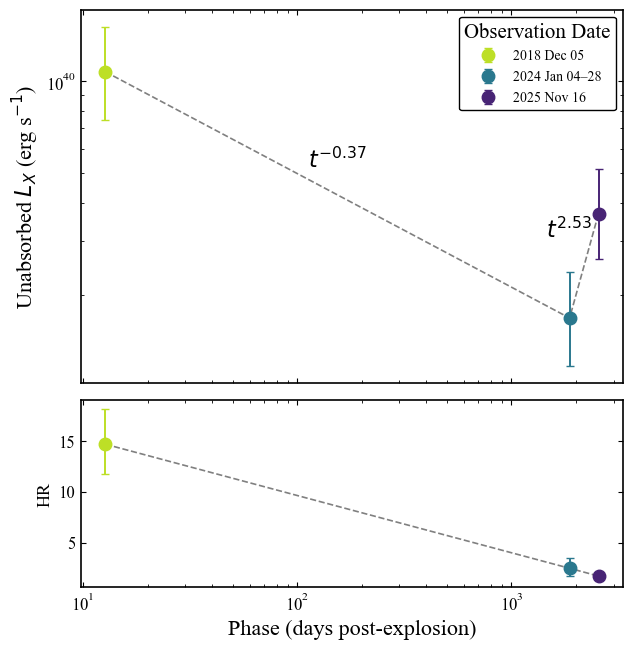

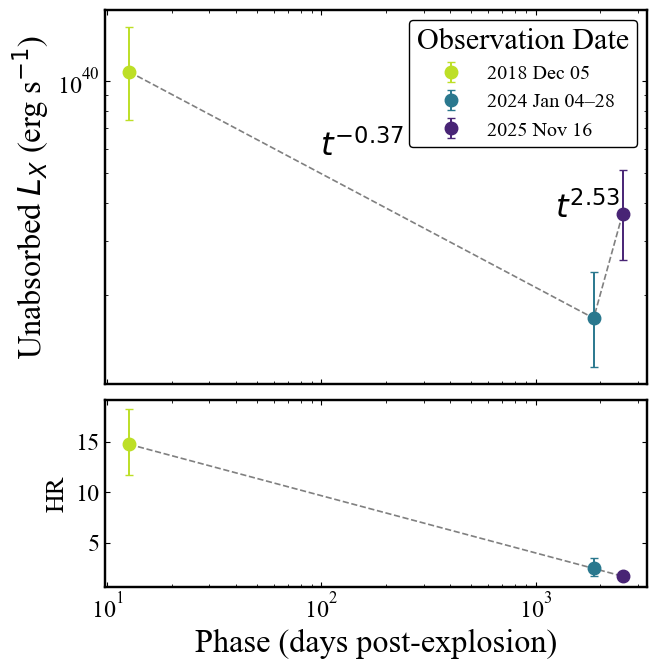

In [2]:
def build_lc_figure(scale=1.0, suffix=""):
    """Build and save one rendering of the luminosity + hardness-ratio figure.

    scale: passed to functions.set_plot_style() -- 1.0 for the standard
    (paper-style) sizes, larger (e.g. 1.45) for a "proposal" rendering with
    bigger text. Explicit fontsize= kwargs below (legend, power-law-index
    annotations, HR ylabel -- none covered by set_plot_style's rcParams) are
    scaled by hand to match.
    suffix: appended to the saved filename, e.g. "_proposal".
    """
    functions.set_plot_style(scale=scale)
    fig, (ax_lum, ax_hr) = plt.subplots(
        2, 1, figsize=(7, 7.5), sharex=True,
        gridspec_kw={"height_ratios": [2, 1], "hspace": 0.06},
    )

    epoch_order = ["20306", "29071_29072", "31211_31996"]
    phases = [df.loc[k, "phase_days"] for k in epoch_order]
    lums = [df.loc[k, "luminosity_central"] for k in epoch_order]
    hrs = [hr_df.loc[k, "hardness_ratio"] for k in epoch_order]

    # Top panel: luminosity.
    ax_lum.plot(phases, lums, linestyle="--", color="gray", lw=1.2, zorder=2)
    for epoch_key in epoch_order:
        row = df.loc[epoch_key]
        ax_lum.errorbar(
            row["phase_days"], row["luminosity_central"],
            yerr=[[row["lum_errlo_total"]], [row["lum_errhi_total"]]],
            fmt="o", ms=9, capsize=3, lw=1.4, elinewidth=1.4,
            color=epoch_colors[epoch_key], zorder=3,
            label=EPOCH_LABELS[epoch_key],
        )

    # Power-law index (L ~ t^index) between each consecutive pair of epochs --
    # same anchor/offset tuning as before (not re-derived per scale).
    label_log_fracs = [0.5, 0.35]
    label_offsets_pts = [(0, 16), (-8, 28)]
    for (t1, L1), (t2, L2), frac, (dx, dy) in zip(
        zip(phases[:-1], lums[:-1]), zip(phases[1:], lums[1:]),
        label_log_fracs, label_offsets_pts,
    ):
        index = np.log(L2 / L1) / np.log(t2 / t1)
        t_anchor = t1 * (t2 / t1) ** frac
        L_anchor = L1 * (L2 / L1) ** frac
        ax_lum.annotate(
            rf"$t^{{{index:.2f}}}$",
            xy=(t_anchor, L_anchor), xycoords="data",
            xytext=(dx * scale, dy * scale), textcoords="offset points",
            fontsize=16 * scale, ha="center", va="bottom",
        )

    ax_lum.set_yscale("log")
    ax_lum.set_ylabel(r"Unabsorbed $L_X$ (erg s$^{-1}$)")
    ax_lum.tick_params(labelbottom=False)
    ax_lum.legend(
        title="Observation Date", fontsize=10 * scale, title_fontsize=15 * scale,
        frameon=True, edgecolor="black", framealpha=1, loc="best",
    )

    # Bottom panel: hardness ratio, sharing the x-axis with the panel above.
    ax_hr.plot(phases, hrs, linestyle="--", color="gray", lw=1.2, zorder=2)
    for epoch_key in epoch_order:
        row = hr_df.loc[epoch_key]
        ax_hr.errorbar(
            row["phase_days"], row["hardness_ratio"],
            yerr=[[row["hr_errlo"]], [row["hr_errhi"]]],
            fmt="o", ms=9, capsize=3, lw=1.4, elinewidth=1.4,
            color=epoch_colors[epoch_key], zorder=3,
        )

    ax_hr.set_xscale("log")
    ax_hr.set_xlabel("Phase (days post-explosion)")
    ax_hr.set_ylabel(r"HR", fontsize=13 * scale)

    fig.savefig(f"../figures/xray_luminosity_light_curve{suffix}.png", dpi=400, bbox_inches="tight")
    fig.savefig(f"../figures/xray_luminosity_light_curve{suffix}.pdf", bbox_inches="tight")
    return fig


# Standard (paper-style) rendering -- unchanged filenames.
build_lc_figure(scale=1.0, suffix="")
plt.show()

# Proposal rendering -- larger fonts throughout (JWST proposal figures are
# typically embedded smaller than a paper figure, so text needs to start
# bigger to stay legible). Separate files, doesn't touch the standard ones.
build_lc_figure(scale=1.45, suffix="_proposal")
plt.show()